# Evaluating Model Performance: Metrics and Diagnostics

## Datasets and Setup

### Dataset Choice

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
    RocCurveDisplay, PrecisionRecallDisplay, brier_score_loss
)

# ══════════════════════════════════════════════════════════════════════════
# Dataset A — Adult Income (classification, class imbalance)
# ══════════════════════════════════════════════════════════════════════════
adult_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/adult/adult.data"
)
adult_cols = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]
df_adult = pd.read_csv(adult_url, names=adult_cols,
                       na_values=" ?", skipinitialspace=True)
df_adult["income"] = (df_adult["income"].str.strip() == ">50K").astype(int)
df_adult = df_adult.dropna()

cat_cols_adult = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]
num_cols_adult = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week"
]

X_adult = df_adult[num_cols_adult + cat_cols_adult]
y_adult = df_adult["income"]

X_atr, X_ate, y_atr, y_ate = train_test_split(
    X_adult, y_adult,
    test_size=0.20, stratify=y_adult, random_state=RANDOM_SEED
)

print("=== Adult Income (classification) ===")
print(f"  Train : {X_atr.shape[0]:,}   Test : {X_ate.shape[0]:,}")
print(f"  Class balance — train : {y_atr.mean():.3f}  test : {y_ate.mean():.3f}")

# ══════════════════════════════════════════════════════════════════════════
# Dataset B — Medical Insurance Cost (regression, right-skewed target)
# ══════════════════════════════════════════════════════════════════════════
ins_url = (
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets"
    "/master/insurance.csv"
)
df_ins = pd.read_csv(ins_url)
num_cols_ins = ["age", "bmi", "children"]
cat_cols_ins = ["sex", "smoker", "region"]
X_ins = df_ins[num_cols_ins + cat_cols_ins]
y_ins = df_ins["charges"].astype(float)

X_itr, X_ite, y_itr, y_ite = train_test_split(
    X_ins, y_ins, test_size=0.20, random_state=RANDOM_SEED
)

print("\n=== Medical Insurance Cost (regression) ===")
print(f"  Train : {X_itr.shape[0]:,}   Test : {X_ite.shape[0]:,}")
print(f"  Charges — mean: ${y_itr.mean():,.0f}  "
      f"std: ${y_itr.std():,.0f}  "
      f"range: [${y_itr.min():,.0f}, ${y_itr.max():,.0f}]")
print(f"  Skewness : {y_itr.skew():.2f}  (>1 indicates substantial right skew)")

=== Adult Income (classification) ===
  Train : 26,048   Test : 6,513
  Class balance — train : 0.241  test : 0.241

=== Medical Insurance Cost (regression) ===
  Train : 1,070   Test : 268
  Charges — mean: $13,346  std: $12,020  range: [$1,122, $62,593]
  Skewness : 1.52  (>1 indicates substantial right skew)


### Shared Pipeline Factories

In [3]:
def adult_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols_adult),
        ("cat", cat_pipe, cat_cols_adult)
    ])

def make_adult_pipe(clf):
    return Pipeline([
        ("preprocessor", adult_preprocessor()),
        ("clf",           clf)
    ])

def ins_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols_ins),
        ("cat", cat_pipe, cat_cols_ins)
    ])

def make_ins_pipe(reg):
    return Pipeline([
        ("preprocessor", ins_preprocessor()),
        ("reg",           reg)
    ])

# ── Fit baseline models ───────────────────────────────────────────────────
gb_adult = make_adult_pipe(
    GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=RANDOM_SEED
    )
)
gb_adult.fit(X_atr, y_atr)
y_pred_adult  = gb_adult.predict(X_ate)
y_proba_adult = gb_adult.predict_proba(X_ate)[:, 1]

gb_ins = make_ins_pipe(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_SEED
    )
)
gb_ins.fit(X_itr, y_itr)
y_pred_ins = gb_ins.predict(X_ite)

print("Baseline Gradient Boosting — Adult Income")
print(f"  Accuracy : {accuracy_score(y_ate, y_pred_adult):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_ate, y_proba_adult):.4f}")
print(f"\nBaseline Gradient Boosting — Medical Insurance Cost")
print(f"  RMSE     : ${np.sqrt(mean_squared_error(y_ite, y_pred_ins)):,.0f}")
print(f"  R²       : {r2_score(y_ite, y_pred_ins):.4f}")

Baseline Gradient Boosting — Adult Income
  Accuracy : 0.8730
  AUC-ROC  : 0.9310

Baseline Gradient Boosting — Medical Insurance Cost
  RMSE     : $4,658
  R²       : 0.8602


## Regression Metrics — A Systematic Treatment 

### Comparing Metrics on Medical Insurance Cost

In [4]:
models_ins = {
    "Ridge":             make_ins_pipe(Ridge(alpha=10.0)),
    "Gradient Boosting": gb_ins,
}
for name, m in models_ins.items():
    if name != "Gradient Boosting":
        m.fit(X_itr, y_itr)

def all_reg_metrics(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label:28s}  RMSE=${rmse:>7,.0f}  MAE=${mae:>6,.0f}  "
          f"MAPE={mape:5.1f}%  R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

print("=== Medical Insurance Cost Test Set Metrics ===")
for name, m in models_ins.items():
    all_reg_metrics(m.predict(X_ite), y_ite, label=name)

=== Medical Insurance Cost Test Set Metrics ===
Ridge                         RMSE=$  5,854  MAE=$ 4,300  MAPE= 54.0%  R²=0.6735
Gradient Boosting             RMSE=$  4,658  MAE=$ 2,552  MAPE= 35.5%  R²=0.8505


### The Log-Transform Trick for Skewed Targets

In [5]:
y_itr_log = np.log1p(y_itr)

gb_ins_log = make_ins_pipe(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_SEED
    )
)
gb_ins_log.fit(X_itr, y_itr_log)
y_pred_ins_log = np.expm1(gb_ins_log.predict(X_ite))

print("=== Log-transformed vs. raw target ===")
all_reg_metrics(y_ite, y_pred_ins_log, label="GB (log target)")
all_reg_metrics(y_ite, y_pred_ins,     label="GB (raw target)")

=== Log-transformed vs. raw target ===
GB (log target)               RMSE=$  4,681  MAE=$ 2,254  MAPE= 17.7%  R²=0.8589
GB (raw target)               RMSE=$  4,658  MAE=$ 2,552  MAPE= 30.1%  R²=0.8602


{'rmse': np.float64(4658.374872859919),
 'mae': 2551.895871809428,
 'mape': 30.1210453139923,
 'r2': 0.8602213606025981}

### Residual Diagnostics for Metric Choice

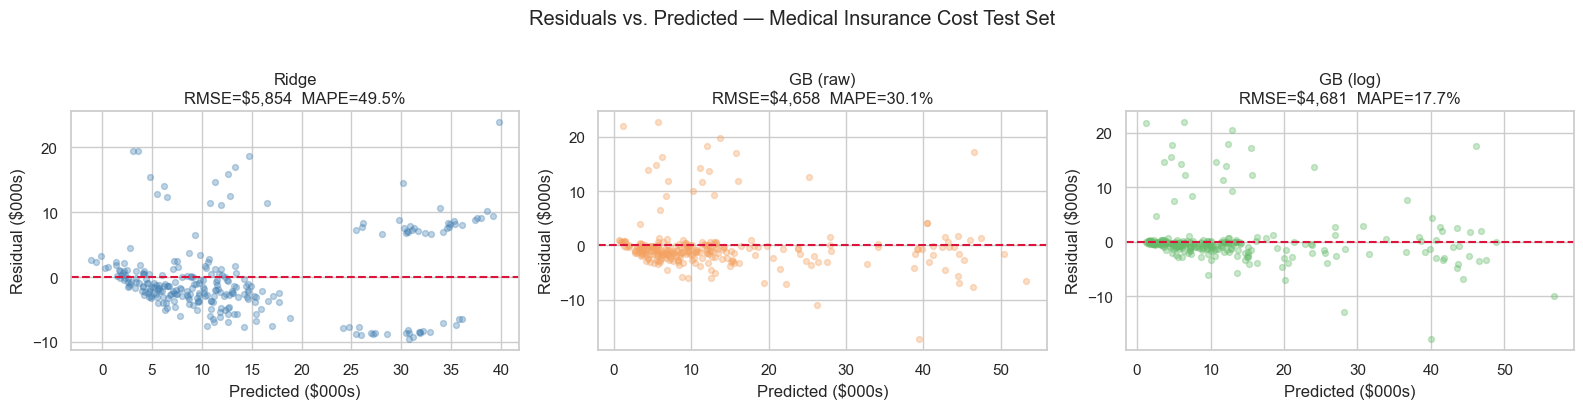

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred_m), color in zip(
    axes,
    [("Ridge", models_ins["Ridge"].predict(X_ite)),
     ("GB (raw)", y_pred_ins),
     ("GB (log)", y_pred_ins_log)],
    ["steelblue", "#F4A261", "#66BB6A"]
):
    resid = y_ite.values - y_pred_m
    ax.scatter(y_pred_m / 1000, resid / 1000,
               alpha=0.35, s=18, color=color)
    ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
    rmse = np.sqrt(mean_squared_error(y_ite, y_pred_m))
    mape = mean_absolute_percentage_error(y_ite, y_pred_m) * 100
    ax.set_title(f"{name}\nRMSE=${rmse:,.0f}  MAPE={mape:.1f}%")
    ax.set_xlabel("Predicted ($000s)")
    ax.set_ylabel("Residual ($000s)")

plt.suptitle("Residuals vs. Predicted — Medical Insurance Cost Test Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch14_ins_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## Classification Metrics — A Systematic Treatment 

### Why Accuracy Fails Under Class Imbalance

In [8]:
y_majority = np.zeros(len(y_ate), dtype=int)
print(f"Majority baseline — Accuracy: {accuracy_score(y_ate, y_majority):.4f}  "
      f"F1: {f1_score(y_ate, y_majority, zero_division=0):.4f}")
print(f"Gradient Boosting — Accuracy: {accuracy_score(y_ate, y_pred_adult):.4f}  "
      f"F1: {f1_score(y_ate, y_pred_adult):.4f}")

Majority baseline — Accuracy: 0.7593  F1: 0.0000
Gradient Boosting — Accuracy: 0.8730  F1: 0.7139


### Full Confusion Matrix Analysis

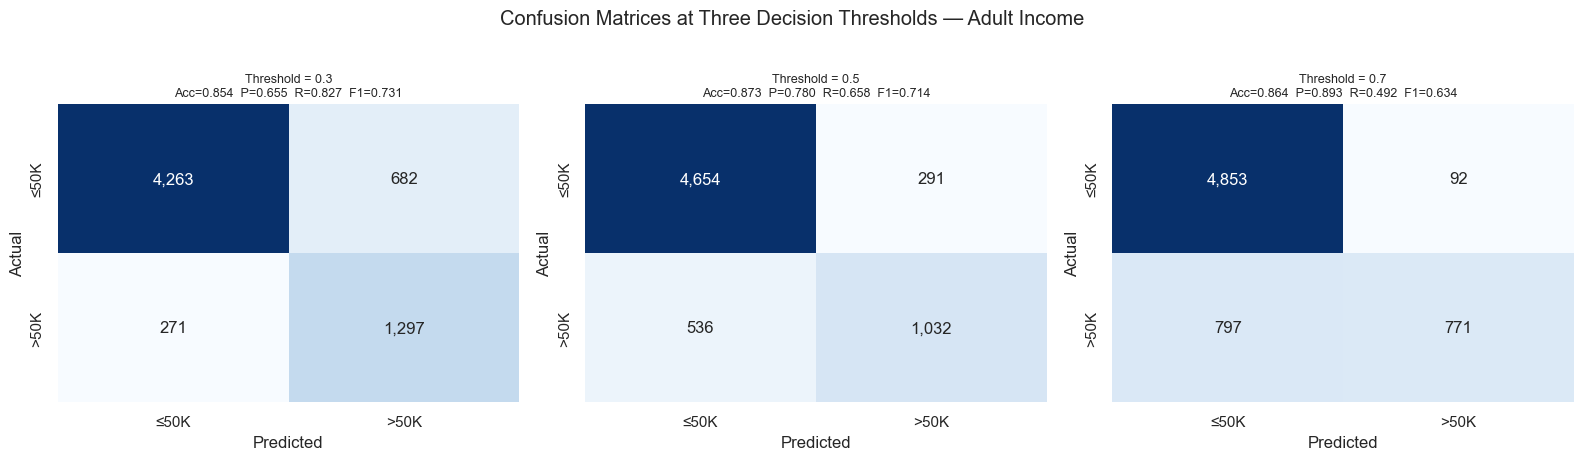

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, thresh in zip(axes, [0.3, 0.5, 0.7]):
    y_pred_t = (y_proba_adult >= thresh).astype(int)
    cm = confusion_matrix(y_ate, y_pred_t)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
                xticklabels=["≤50K", ">50K"],
                yticklabels=["≤50K", ">50K"],
                ax=ax, cbar=False, annot_kws={"size": 12})
    prec = precision_score(y_ate, y_pred_t)
    rec  = recall_score(y_ate, y_pred_t)
    f1   = f1_score(y_ate, y_pred_t)
    acc  = accuracy_score(y_ate, y_pred_t)
    ax.set_title(
        f"Threshold = {thresh}\n"
        f"Acc={acc:.3f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}",
        fontsize=9
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices at Three Decision Thresholds — Adult Income",
             y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch14_confmat_thresh.png", dpi=150, bbox_inches="tight")
plt.show()

### The ROC Curve and Precision-Recall Curve

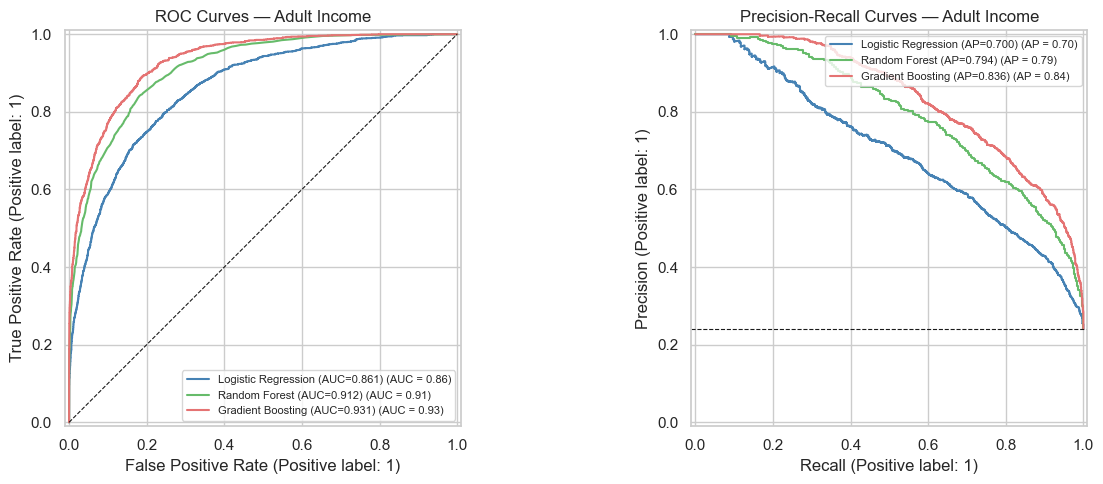

Model                         Acc      F1   ROC-AUC      AP
-------------------------------------------------------
Logistic Regression        0.8279  0.5616    0.8608  0.7003
Random Forest              0.8624  0.6936    0.9123  0.7944
Gradient Boosting          0.8730  0.7139    0.9310  0.8360


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lr_adult = make_adult_pipe(
    LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
)
lr_adult.fit(X_atr, y_atr)
y_proba_lr_adult = lr_adult.predict_proba(X_ate)[:, 1]

rf_adult = make_adult_pipe(
    RandomForestClassifier(
        n_estimators=200, max_features="sqrt",
        random_state=RANDOM_SEED, n_jobs=-1
    )
)
rf_adult.fit(X_atr, y_atr)
y_proba_rf_adult = rf_adult.predict_proba(X_ate)[:, 1]

model_probas = {
    "Logistic Regression":  (y_proba_lr_adult,  "steelblue"),
    "Random Forest":        (y_proba_rf_adult,   "#66BB6A"),
    "Gradient Boosting":    (y_proba_adult,       "#E57373"),
}

for name, (proba, color) in model_probas.items():
    RocCurveDisplay.from_predictions(
        y_ate, proba,
        name=f"{name} (AUC={roc_auc_score(y_ate, proba):.3f})",
        ax=axes[0], color=color
    )
    PrecisionRecallDisplay.from_predictions(
        y_ate, proba,
        name=f"{name} (AP={average_precision_score(y_ate, proba):.3f})",
        ax=axes[1], color=color
    )

axes[0].plot([0,1],[0,1],"k--",lw=0.8)
axes[0].set_title("ROC Curves — Adult Income")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].axhline(y_ate.mean(), color="k", linestyle="--", lw=0.8)
axes[1].set_title("Precision-Recall Curves — Adult Income")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES / "ch14_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Model':25s}  {'Acc':>6}  {'F1':>6}  {'ROC-AUC':>8}  {'AP':>6}")
print("-" * 55)
for name, (proba, _) in model_probas.items():
    y_p = (proba >= 0.5).astype(int)
    print(f"{name:25s}  {accuracy_score(y_ate, y_p):6.4f}  "
          f"{f1_score(y_ate, y_p):6.4f}  "
          f"{roc_auc_score(y_ate, proba):8.4f}  "
          f"{average_precision_score(y_ate, proba):6.4f}")

## Calibration and Probability Quality

### Why Calibration Matters

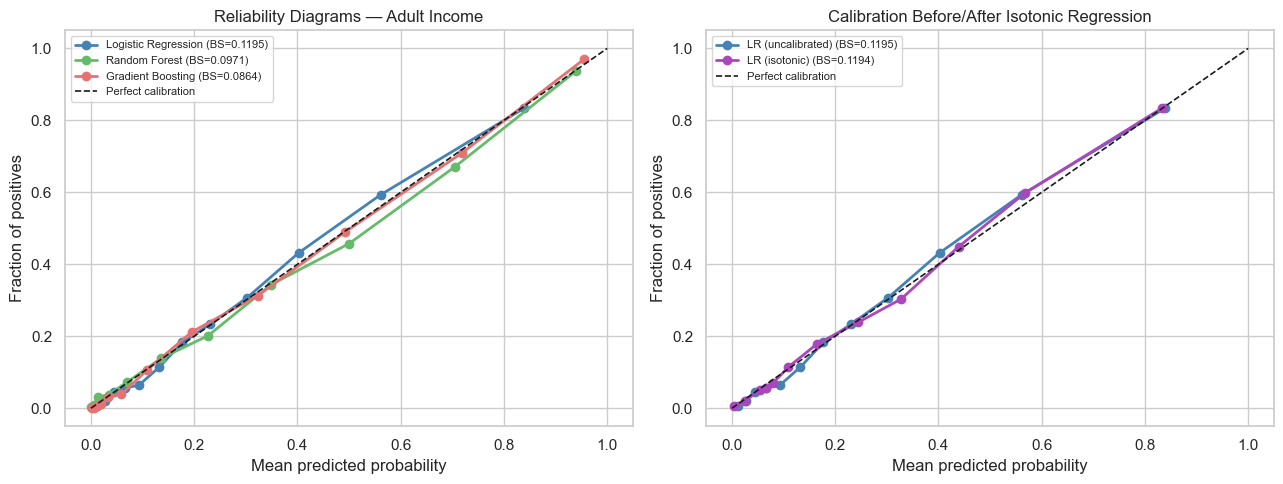

LR Brier score (uncalibrated) : 0.1195
LR Brier score (calibrated)   : 0.1194
GB Brier score                : 0.0864


In [11]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (proba, color) in model_probas.items():
    prob_true, prob_pred = calibration_curve(
        y_ate, proba, n_bins=12, strategy="quantile"
    )
    bs = brier_score_loss(y_ate, proba)
    axes[0].plot(prob_pred, prob_true, "o-", color=color, lw=2,
                 label=f"{name} (BS={bs:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect calibration")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Reliability Diagrams — Adult Income")
axes[0].legend(fontsize=8)

# ── Isotonic calibration for logistic regression ──────────────────────────
lr_calibrated = CalibratedClassifierCV(
    make_adult_pipe(
        LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
    ),
    method="isotonic", cv=5
)
lr_calibrated.fit(X_atr, y_atr)
y_proba_lr_cal = lr_calibrated.predict_proba(X_ate)[:, 1]

for (name, proba, color) in [
    ("LR (uncalibrated)", y_proba_lr_adult, "steelblue"),
    ("LR (isotonic)",     y_proba_lr_cal,   "#AB47BC"),
]:
    prob_true, prob_pred = calibration_curve(
        y_ate, proba, n_bins=12, strategy="quantile"
    )
    bs = brier_score_loss(y_ate, proba)
    axes[1].plot(prob_pred, prob_true, "o-", color=color, lw=2,
                 label=f"{name} (BS={bs:.4f})")

axes[1].plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect calibration")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Fraction of positives")
axes[1].set_title("Calibration Before/After Isotonic Regression")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch14_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"LR Brier score (uncalibrated) : {brier_score_loss(y_ate, y_proba_lr_adult):.4f}")
print(f"LR Brier score (calibrated)   : {brier_score_loss(y_ate, y_proba_lr_cal):.4f}")
print(f"GB Brier score                : {brier_score_loss(y_ate, y_proba_adult):.4f}")